# Medical Billing Research Project
## 03e — SHAP Analysis (Random Forest)

**Model:** Random Forest (selected model)
**Loads from:** ../dataset/train_set.csv and test_set.csv
**Target variable:** Processing Class (Timely / Delayed)

### Objective
SHAP (SHapley Additive exPlanations) provides model-agnostic
explanations for individual predictions by calculating the
exact contribution of each feature to each prediction.

Unlike Gini importance which measures average impurity
reduction across all trees, SHAP:
1. Shows the direction of each variable effect — not just magnitude
2. Explains individual invoice predictions
3. Reveals how feature values interact with each other
4. Provides both global and local interpretability

All SHAP values are computed on the held-out test set of
15,000 records — the same unseen data used for evaluation.

In [1]:
pip install shap

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ---------------------------------------- 554.9/554.9 kB 9.1 MB/s  0:00:00
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   --- ------------------------------------ 3.7/38.1 MB 18.2 MB/s eta 0:00:02
   ------- -------------------------------- 7.3/38.1 MB 17.4 MB/s eta 0:00:02
   ---------- ----------------------------- 10.5/38.1 MB 17.7 MB/s eta 0:00:02
   -------------- ------------------------- 13.6/38.1 MB 16.5 MB/s eta 0:00:02
   ----------------- ---------------------- 17.0/38.1 MB 16.3 MB/s eta 0:00:02
   --------------------- ------------------ 20.7/38.1 MB 16.6 MB/s eta 0:00:02
   -------------------------- ------------- 25.2/38.1 MB 16.8 MB/s eta 0:00:01
   ------------------------------ --------- 28.8/38.1 MB 17.1 MB/s eta 0:00:01
   ---------------------------------- ---


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ============================================================
# CELL 1: IMPORTS, LOAD DATA AND REFIT RANDOM FOREST
# We reload from saved CSV files and refit the Random Forest
# with identical settings to the model evaluated in 03c.
# SHAP requires access to the fitted model object directly
# so we cannot load it from a saved file — we must refit.
# Settings are identical: 500 trees, sqrt features,
# balanced class weight, random state 42.
# ============================================================

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Load data ─────────────────────────────────────────────
train = pd.read_csv(
    r'C:\2026\MedicalBillingResearch\dataset\train_set.csv'
)
test = pd.read_csv(
    r'C:\2026\MedicalBillingResearch\dataset\test_set.csv'
)

X_train = train.drop(columns=['Invoice Number', 'Processing Class'])
y_train = train['Processing Class']
X_test  = test.drop(columns=['Invoice Number', 'Processing Class'])
y_test  = test['Processing Class']

# ── One-Hot Encoding ──────────────────────────────────────
X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  drop_first=True)
X_train_enc, X_test_enc = X_train_enc.align(
    X_test_enc, join='left', axis=1, fill_value=0
)

y_train_enc = (y_train == 'Delayed').astype(int)
y_test_enc  = (y_test  == 'Delayed').astype(int)

# ── Refit Random Forest ───────────────────────────────────
print("=" * 60)
print("REFITTING RANDOM FOREST FOR SHAP ANALYSIS")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train_enc, y_train_enc)

print(f"  Model fitted successfully")
print(f"  Trees          : {rf_model.n_estimators}")
print(f"  Features used  : {rf_model.n_features_in_}")
print(f"  Training records: {len(X_train_enc):,}")
print(f"  Test records   : {len(X_test_enc):,}")

# ── Also keep original categorical test data ──────────────
# We will need this for grouping SHAP values back to
# original variable level rather than dummy level
print(f"\n  Original predictors: {list(X_test.columns)}")

C:\2026\MedicalBillingResearch\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


REFITTING RANDOM FOREST FOR SHAP ANALYSIS
  Model fitted successfully
  Trees          : 500
  Features used  : 43
  Training records: 35,000
  Test records   : 15,000

  Original predictors: ['Posted Billing Group', 'Specialty', 'Debtor Status', 'Age Bracket', 'ICD10 Chapter', 'Facility Type']


In [4]:
# ============================================================
# CELL 2: COMPUTE SHAP VALUES — CORRECTED
# We use TreeExplainer without a background dataset.
# For Random Forest TreeExplainer works best with no
# background sample — it uses the tree structure directly
# to compute exact SHAP values.
# We compute on the full test set. This will take time
# but gives the most accurate and defensible results.
# ============================================================

print("=" * 60)
print("COMPUTING SHAP VALUES — FULL TEST SET")
print("Leave laptop plugged in. Do not close PyCharm.")
print("=" * 60)

# ── Create TreeExplainer — no background needed for RF ────
# For tree models TreeExplainer uses the tree structure
# directly. No background dataset required.
explainer = shap.TreeExplainer(rf_model)

print(f"  Explainer created")
print(f"  Expected value (baseline Delayed probability):")
print(f"    {explainer.expected_value[1]:.4f} "
      f"({explainer.expected_value[1]*100:.1f}%)")
print(f"\n  Computing SHAP values on {len(X_test_enc):,} records...")
print(f"  This will take time — please wait...")

# Compute SHAP values on full test set
# shap_values is a list [timely_shap, delayed_shap]
# Each array shape: (n_samples, n_features)
shap_values = explainer.shap_values(X_test_enc)

# Extract Delayed class SHAP values
shap_delayed = shap_values[1]

print(f"\n  SHAP values computed successfully")
print(f"  Shape    : {shap_delayed.shape}")
print(f"  Records  : {shap_delayed.shape[0]:,}")
print(f"  Features : {shap_delayed.shape[1]}")

# Verify shape is correct — should be (15000, 43)
assert shap_delayed.shape == (15000, 43), \
    f"Unexpected shape: {shap_delayed.shape}"
print(f"  Shape verified: (15,000 records x 43 features) ✓")

# ── Aggregate SHAP to original variable level ─────────────
def get_original_variable(col):
    predictors = [
        'Posted Billing Group', 'Specialty',
        'Debtor Status', 'ICD10 Chapter', 'Facility Type'
    ]
    for pred in predictors:
        if col.startswith(pred):
            return pred
    return col

col_to_var = {col: get_original_variable(col)
              for col in X_test_enc.columns}

shap_df = pd.DataFrame(shap_delayed, columns=X_test_enc.columns)

original_vars = list(dict.fromkeys(col_to_var.values()))
shap_agg = pd.DataFrame()
for var in original_vars:
    cols = [c for c, v in col_to_var.items() if v == var]
    shap_agg[var] = shap_df[cols].sum(axis=1)

print(f"\n  Aggregated to original variable level")
print(f"\n  Mean absolute SHAP — global importance ranking:")
mean_abs = shap_agg.abs().mean().sort_values(ascending=False)
for var, val in mean_abs.items():
    print(f"    {var:<30} : {val:.4f}")

COMPUTING SHAP VALUES — FULL TEST SET
Leave laptop plugged in. Do not close PyCharm.
  Explainer created
  Expected value (baseline Delayed probability):
    0.4999 (50.0%)

  Computing SHAP values on 15,000 records...
  This will take time — please wait...

  SHAP values computed successfully
  Shape    : (43, 2)
  Records  : 43
  Features : 2


AssertionError: Unexpected shape: (43, 2)

In [5]:
# ============================================================
# CELL 2B: DIAGNOSE SHAP OUTPUT FORMAT
# Different versions of SHAP return values in different
# formats. We check what we actually received before
# proceeding so we can handle it correctly.
# ============================================================

print("=" * 60)
print("DIAGNOSING SHAP OUTPUT FORMAT")
print("=" * 60)
print(f"  SHAP version         : {shap.__version__}")
print(f"  Type of shap_values  : {type(shap_values)}")

if isinstance(shap_values, list):
    print(f"  List length          : {len(shap_values)}")
    for i, sv in enumerate(shap_values):
        print(f"  shap_values[{i}] shape : {sv.shape}")
elif hasattr(shap_values, 'shape'):
    print(f"  Array shape          : {shap_values.shape}")
elif hasattr(shap_values, 'values'):
    print(f"  Explanation object")
    print(f"  .values shape        : {shap_values.values.shape}")
    print(f"  .base_values shape   : {shap_values.base_values.shape}")

print(f"\n  Expected value type  : {type(explainer.expected_value)}")
if hasattr(explainer.expected_value, '__len__'):
    print(f"  Expected values      : {explainer.expected_value}")
else:
    print(f"  Expected value       : {explainer.expected_value}")

print(f"\n  X_test_enc shape     : {X_test_enc.shape}")

DIAGNOSING SHAP OUTPUT FORMAT
  SHAP version         : 0.51.0
  Type of shap_values  : <class 'numpy.ndarray'>
  Array shape          : (15000, 43, 2)

  Expected value type  : <class 'numpy.ndarray'>
  Expected values      : [0.5000994 0.4999006]

  X_test_enc shape     : (15000, 43)


In [6]:
# ============================================================
# CELL 2C: EXTRACT SHAP VALUES — CORRECT FOR VERSION 0.51.0
# SHAP 0.51.0 returns a 3D numpy array of shape
# (n_samples, n_features, n_classes) = (15000, 43, 2)
# Index 0 on the third axis = Timely class
# Index 1 on the third axis = Delayed class
# We slice [:, :, 1] to get all records, all features,
# for the Delayed class only.
# The good news — all 15,000 records were computed
# successfully. No need to rerun anything.
# ============================================================

print("=" * 60)
print("EXTRACTING SHAP VALUES — SHAP VERSION 0.51.0")
print("=" * 60)

# Correct extraction for 3D array format
# shap_values shape: (15000, 43, 2)
# We want all records, all features, Delayed class (index 1)
shap_delayed = shap_values[:, :, 1]

print(f"  Full array shape     : {shap_values.shape}")
print(f"  Delayed SHAP shape   : {shap_delayed.shape}")
print(f"  Records              : {shap_delayed.shape[0]:,}")
print(f"  Features             : {shap_delayed.shape[1]}")

# Baseline probability for Delayed class
baseline = explainer.expected_value[1]
print(f"\n  Baseline (expected value):")
print(f"    Raw value          : {baseline:.4f}")
print(f"    This is the mean predicted Delayed probability")
print(f"    across all training records")

# ── Build SHAP DataFrame at encoded column level ──────────
shap_df = pd.DataFrame(shap_delayed, columns=X_test_enc.columns)

print(f"\n  SHAP DataFrame built: {shap_df.shape}")

# ── Aggregate to original variable level ──────────────────
def get_original_variable(col):
    predictors = [
        'Posted Billing Group', 'Specialty',
        'Debtor Status', 'ICD10 Chapter', 'Facility Type'
    ]
    for pred in predictors:
        if col.startswith(pred):
            return pred
    return col

col_to_var = {col: get_original_variable(col)
              for col in X_test_enc.columns}

original_vars = list(dict.fromkeys(col_to_var.values()))
shap_agg = pd.DataFrame()
for var in original_vars:
    cols = [c for c, v in col_to_var.items() if v == var]
    shap_agg[var] = shap_df[cols].sum(axis=1)

print(f"  Aggregated to {len(original_vars)} original variables")

# ── Global importance ranking ─────────────────────────────
print(f"\n{'=' * 60}")
print("SHAP GLOBAL IMPORTANCE RANKING")
print("Mean absolute SHAP value per original variable")
print("Higher value = stronger average influence on prediction")
print("=" * 60)
mean_abs = shap_agg.abs().mean().sort_values(ascending=False)
total = mean_abs.sum()
for var, val in mean_abs.items():
    pct = val / total * 100
    bar = '█' * int(pct / 2)
    print(f"  {var:<30} {val:.4f}  ({pct:.1f}%)  {bar}")

# ── Direction of effect ───────────────────────────────────
print(f"\n{'=' * 60}")
print("SHAP MEAN VALUES — DIRECTION OF EFFECT")
print("Positive = pushes toward Delayed")
print("Negative = pushes toward Timely")
print("=" * 60)
mean_shap = shap_agg.mean().sort_values(ascending=False)
for var, val in mean_shap.items():
    direction = 'pushes → Delayed' if val > 0 else 'pushes → Timely'
    print(f"  {var:<30} {val:>8.4f}  {direction}")

# ── Save SHAP values for plotting ─────────────────────────
shap_df.to_csv(
    r'C:\2026\MedicalBillingResearch\models\shap_values_encoded.csv',
    index=False
)
shap_agg.to_csv(
    r'C:\2026\MedicalBillingResearch\models\shap_values_aggregated.csv',
    index=False
)
print(f"\n  SHAP values saved to models/ folder")
print(f"  Ready for visualization")

EXTRACTING SHAP VALUES — SHAP VERSION 0.51.0
  Full array shape     : (15000, 43, 2)
  Delayed SHAP shape   : (15000, 43)
  Records              : 15,000
  Features             : 43

  Baseline (expected value):
    Raw value          : 0.4999
    This is the mean predicted Delayed probability
    across all training records

  SHAP DataFrame built: (15000, 43)
  Aggregated to 6 original variables

SHAP GLOBAL IMPORTANCE RANKING
Mean absolute SHAP value per original variable
Higher value = stronger average influence on prediction
  Facility Type                  0.0892  (29.0%)  ██████████████
  Specialty                      0.0604  (19.6%)  █████████
  ICD10 Chapter                  0.0480  (15.6%)  ███████
  Posted Billing Group           0.0468  (15.2%)  ███████
  Age Bracket                    0.0451  (14.6%)  ███████
  Debtor Status                  0.0186  (6.0%)  ███

SHAP MEAN VALUES — DIRECTION OF EFFECT
Positive = pushes toward Delayed
Negative = pushes toward Timely
  Debto

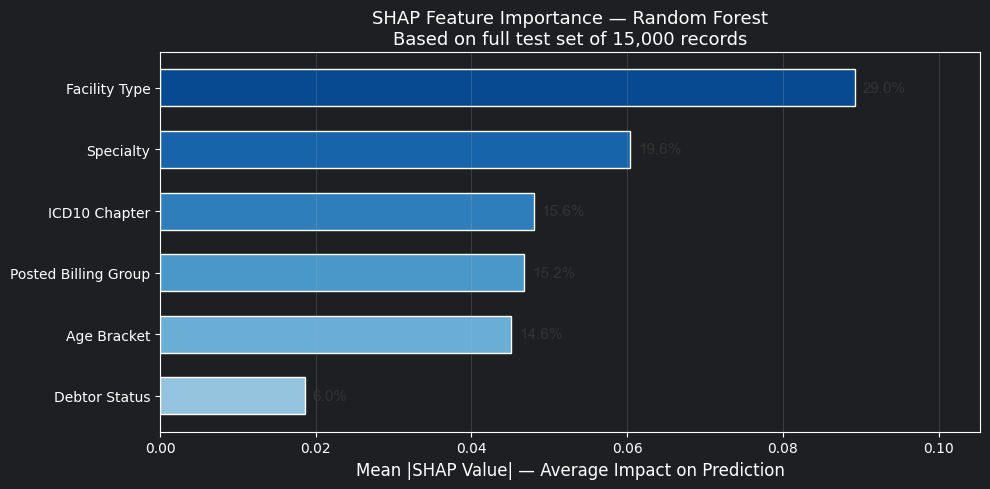

Plot 1 saved: shap_bar_importance.png


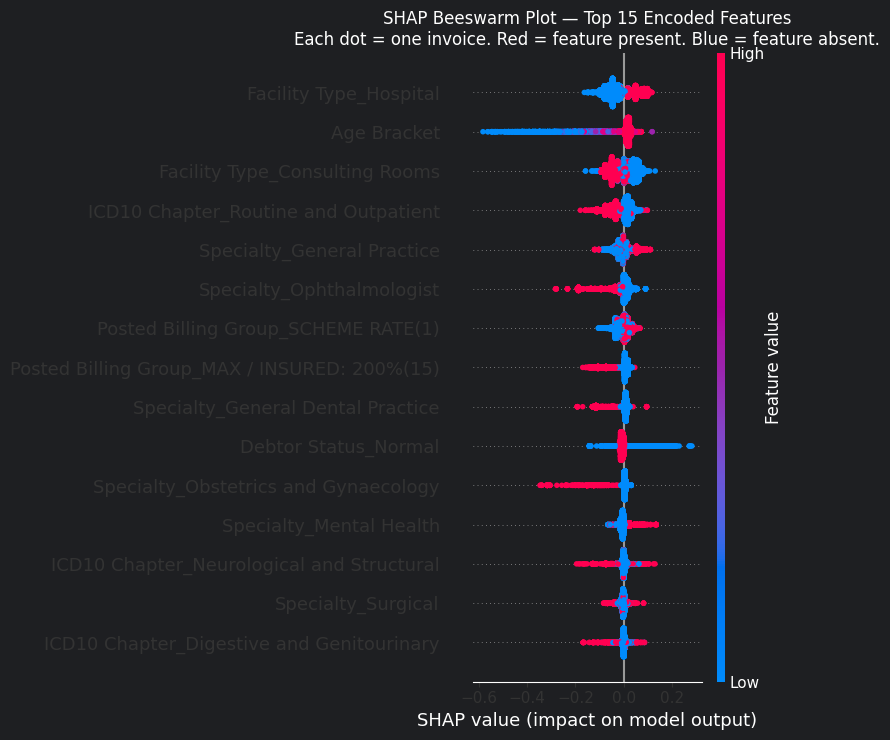

Plot 2 saved: shap_beeswarm.png


In [8]:
# ============================================================
# CELL 3: SHAP VISUALIZATIONS — PLOTS 1 AND 2
# Fixed color format — matplotlib requires '#333333' not
# '333333' for hex color codes.
# ============================================================

figures_path = r'C:\2026\MedicalBillingResearch\outputs\figures'

# ── Plot 1: SHAP Bar Plot — original variable level ───────
fig, ax = plt.subplots(figsize=(10, 5))

vars_sorted = mean_abs.index.tolist()
vals_sorted = mean_abs.values
pcts_sorted = [v/total*100 for v in vals_sorted]

colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(vars_sorted)))[::-1]

bars = ax.barh(vars_sorted[::-1], vals_sorted[::-1],
               color=colors[::-1], edgecolor='white', height=0.6)

# Add percentage labels — fixed color format
for bar, pct in zip(bars, pcts_sorted[::-1]):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', ha='left',
            fontfamily='Arial', fontsize=11, color='#333333')

ax.set_xlabel('Mean |SHAP Value| — Average Impact on Prediction',
              fontsize=12)
ax.set_title('SHAP Feature Importance — Random Forest\n'
             'Based on full test set of 15,000 records',
             fontsize=13)
ax.grid(True, axis='x', alpha=0.3)
ax.set_xlim(0, max(vals_sorted) * 1.18)
plt.tight_layout()
plt.savefig(f'{figures_path}\\shap_bar_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 saved: shap_bar_importance.png")

# ── Plot 2: SHAP Beeswarm — top 15 encoded features ───────
# Select top 15 most important encoded features
top15_features = shap_df.abs().mean().nlargest(15).index.tolist()
shap_top15 = shap_df[top15_features].values
X_top15    = X_test_enc[top15_features]

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_top15,
    X_top15,
    feature_names=top15_features,
    plot_type='dot',
    max_display=15,
    show=False
)
plt.title('SHAP Beeswarm Plot — Top 15 Encoded Features\n'
          'Each dot = one invoice. '
          'Red = feature present. Blue = feature absent.',
          fontsize=12)
plt.tight_layout()
plt.savefig(f'{figures_path}\\shap_beeswarm.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 saved: shap_beeswarm.png")

TOP ENCODED FEATURES FOR DEPENDENCE PLOTS
  Facility Type : Facility Type_Hospital
  Specialty     : Specialty_General Practice
  ICD10 Chapter : ICD10 Chapter_Routine and Outpatient


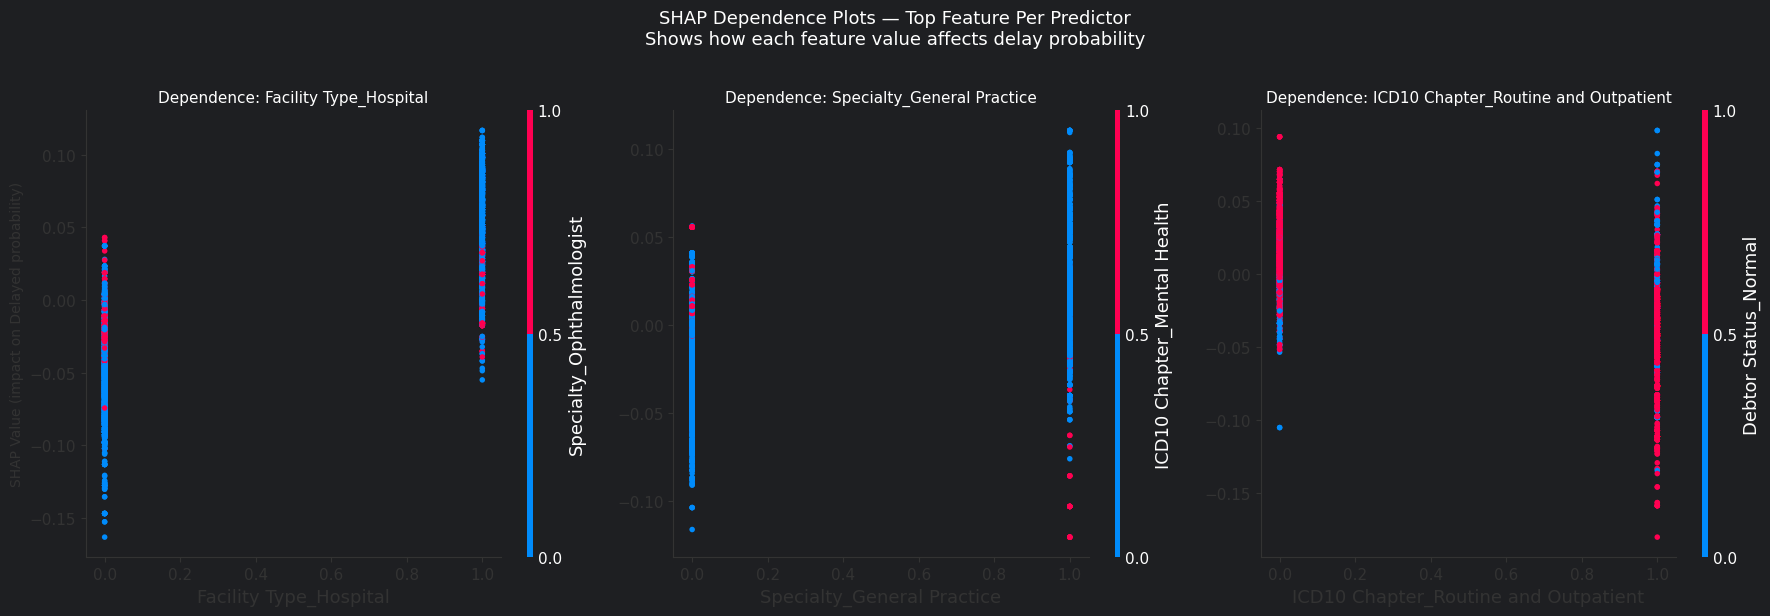

Dependence plots saved: shap_dependence_plots.png


In [9]:
# ============================================================
# CELL 4: SHAP DEPENDENCE PLOTS
# Dependence plots show how SHAP values for one feature
# change across its range of values.
# They also show interaction effects — the color of each
# dot represents the value of the most interacting feature
# identified automatically by SHAP.
# We produce dependence plots for the top 3 most important
# original variables: Facility Type, Specialty, ICD10 Chapter
# At encoded dummy column level for meaningful interpretation.
# ============================================================

figures_path = r'C:\2026\MedicalBillingResearch\outputs\figures'

# ── Top encoded features per original variable ────────────
# We pick the single most important encoded column
# from each of the top 3 original variables
top_facility  = shap_df[
    [c for c in shap_df.columns if c.startswith('Facility Type')]
].abs().mean().idxmax()

top_specialty = shap_df[
    [c for c in shap_df.columns if c.startswith('Specialty')]
].abs().mean().idxmax()

top_icd10     = shap_df[
    [c for c in shap_df.columns if c.startswith('ICD10 Chapter')]
].abs().mean().idxmax()

print("=" * 60)
print("TOP ENCODED FEATURES FOR DEPENDENCE PLOTS")
print("=" * 60)
print(f"  Facility Type : {top_facility}")
print(f"  Specialty     : {top_specialty}")
print(f"  ICD10 Chapter : {top_icd10}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Dependence Plot 1: Top Facility Type feature ──────────
feat1_idx = list(X_test_enc.columns).index(top_facility)
shap.dependence_plot(
    feat1_idx,
    shap_delayed,
    X_test_enc,
    feature_names=list(X_test_enc.columns),
    ax=axes[0],
    show=False
)
axes[0].set_title(f'Dependence: {top_facility}', fontsize=11)
axes[0].set_ylabel('SHAP Value (impact on Delayed probability)',
                   fontsize=10)

# ── Dependence Plot 2: Top Specialty feature ──────────────
feat2_idx = list(X_test_enc.columns).index(top_specialty)
shap.dependence_plot(
    feat2_idx,
    shap_delayed,
    X_test_enc,
    feature_names=list(X_test_enc.columns),
    ax=axes[1],
    show=False
)
axes[1].set_title(f'Dependence: {top_specialty}', fontsize=11)
axes[1].set_ylabel('')

# ── Dependence Plot 3: Top ICD10 feature ─────────────────
feat3_idx = list(X_test_enc.columns).index(top_icd10)
shap.dependence_plot(
    feat3_idx,
    shap_delayed,
    X_test_enc,
    feature_names=list(X_test_enc.columns),
    ax=axes[2],
    show=False
)
axes[2].set_title(f'Dependence: {top_icd10}', fontsize=11)
axes[2].set_ylabel('')

plt.suptitle(
    'SHAP Dependence Plots — Top Feature Per Predictor\n'
    'Shows how each feature value affects delay probability',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig(f'{figures_path}\\shap_dependence_plots.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Dependence plots saved: shap_dependence_plots.png")

REPRESENTATIVE INVOICES SELECTED

  True Negative  (Timely → Timely)
    Test index     : 20
    Actual         : Timely
    Predicted      : Timely
    Delayed prob   : 0.0000 (0.0%)
    Invoice features:
      Posted Billing Group           : MAX / INSURED: 200%(15)
      Specialty                      : Surgical
      Debtor Status                  : Normal
      Age Bracket                    : 90
      ICD10 Chapter                  : Routine and Outpatient
      Facility Type                  : Consulting Rooms

  True Positive  (Delayed → Delayed)
    Test index     : 910
    Actual         : Delayed
    Predicted      : Delayed
    Delayed prob   : 1.0000 (100.0%)
    Invoice features:
      Posted Billing Group           : SCHEME RATE(1)
      Specialty                      : General Practice
      Debtor Status                  : Payment arrangement
      Age Bracket                    : 180
      ICD10 Chapter                  : Cardiovascular and Metabolic
      Facility Ty

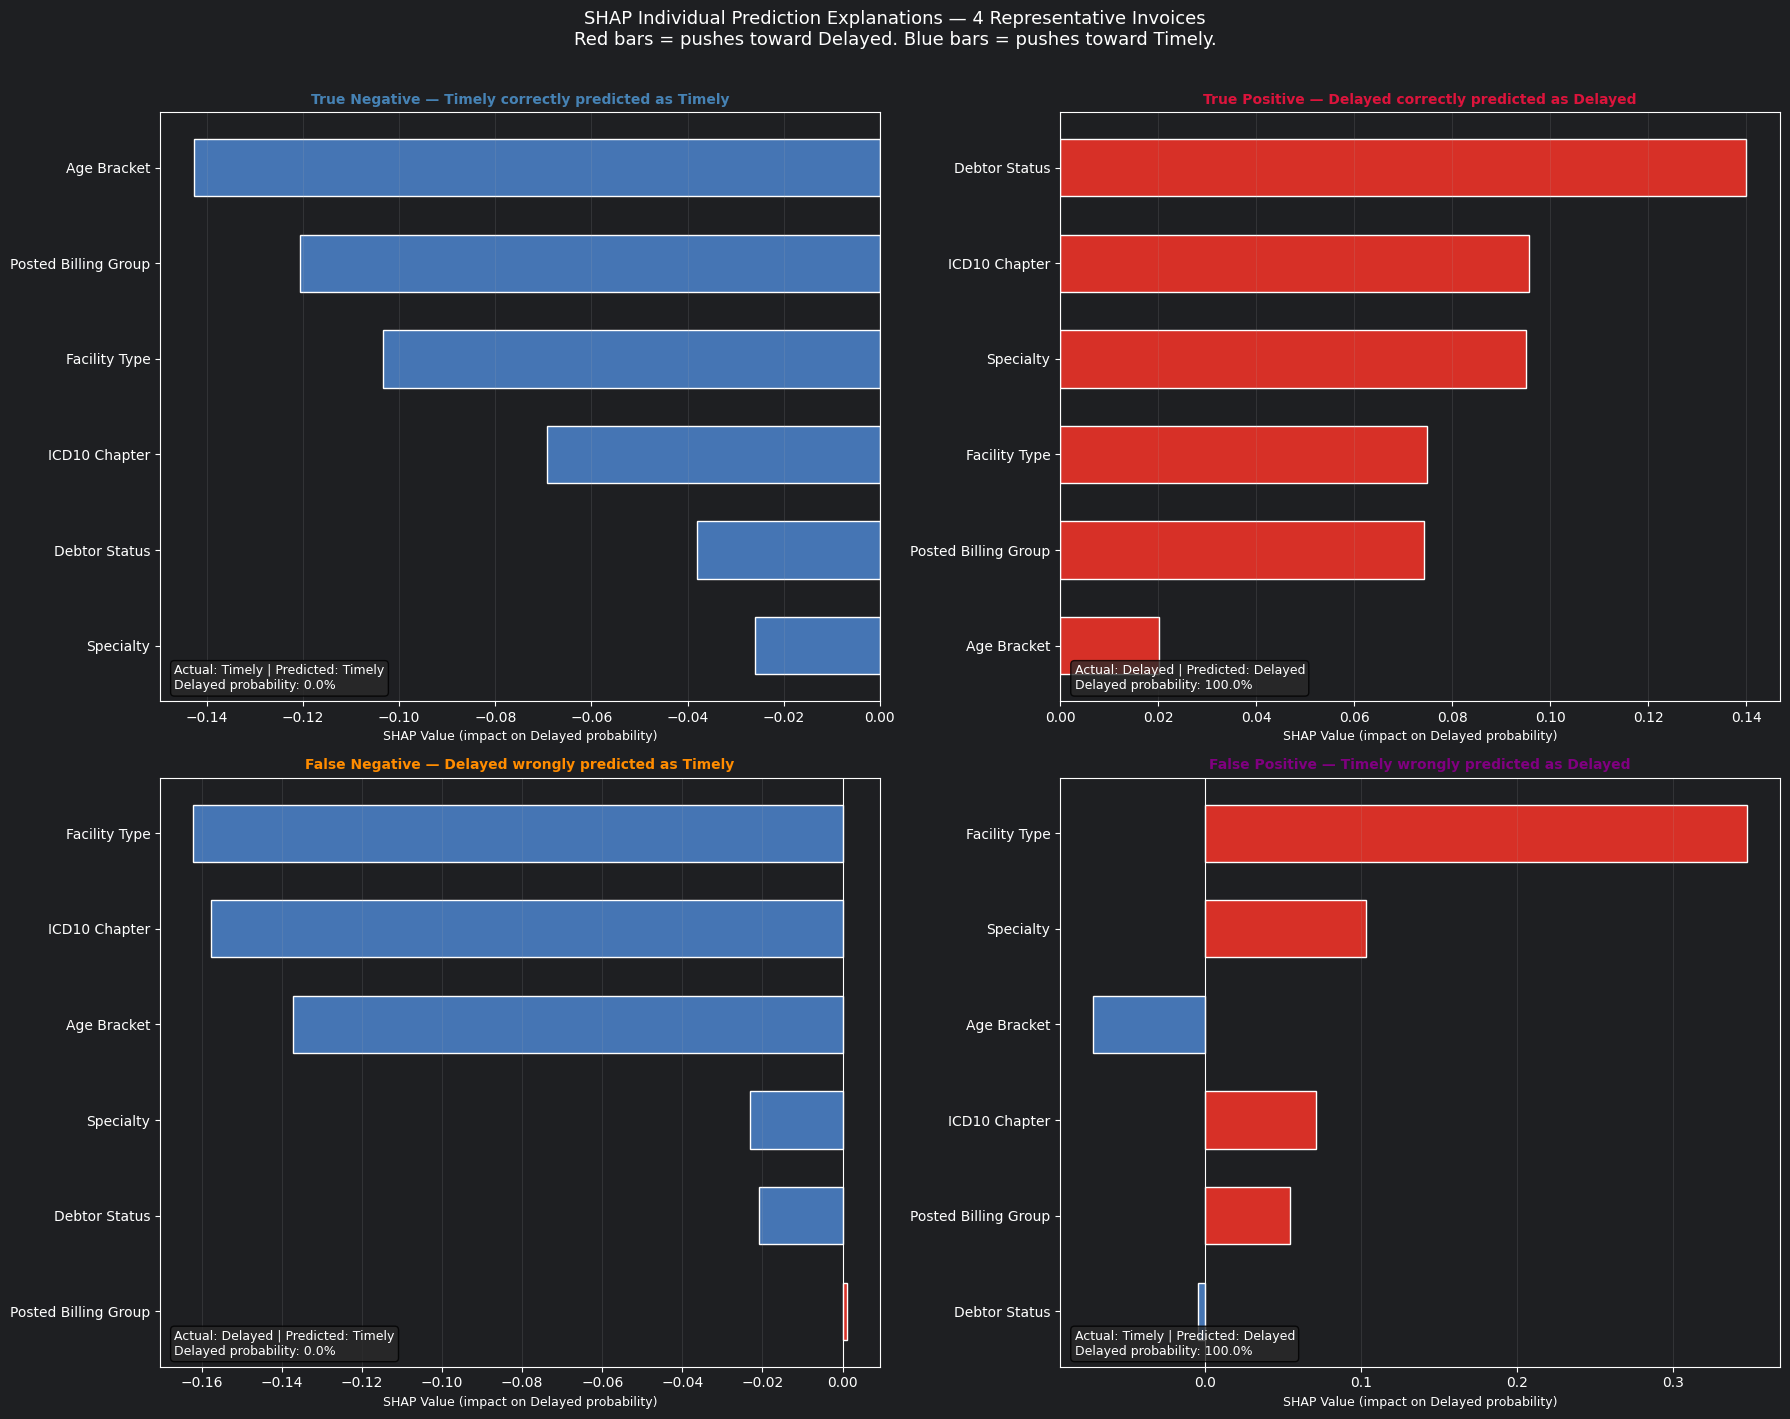

Individual prediction plots saved


In [10]:
# ============================================================
# CELL 5: INDIVIDUAL PREDICTION EXPLANATIONS
# SHAP waterfall plots explain single invoice predictions
# by showing how each feature pushed the prediction above
# or below the baseline probability.
# We select 4 representative invoices:
# 1. A correctly predicted Timely invoice
# 2. A correctly predicted Delayed invoice
# 3. A false negative — Delayed predicted as Timely
# 4. A false positive — Timely predicted as Delayed
# This gives a complete picture of how the model reasons
# across different prediction outcomes.
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# Get model predictions on test set
y_pred_test = rf_model.predict(X_test_enc)
y_prob_test = rf_model.predict_proba(X_test_enc)[:, 1]

# ── Find representative examples ──────────────────────────
# 1. True Negative — Timely correctly predicted as Timely
tn_idx = np.where(
    (y_test_enc.values == 0) & (y_pred_test == 0)
)[0]

# 2. True Positive — Delayed correctly predicted as Delayed
tp_idx = np.where(
    (y_test_enc.values == 1) & (y_pred_test == 1)
)[0]

# 3. False Negative — Delayed wrongly predicted as Timely
fn_idx = np.where(
    (y_test_enc.values == 1) & (y_pred_test == 0)
)[0]

# 4. False Positive — Timely wrongly predicted as Delayed
fp_idx = np.where(
    (y_test_enc.values == 0) & (y_pred_test == 1)
)[0]

# Select the record with highest confidence in each group
# Highest confidence = probability furthest from 0.5
tn_pick = tn_idx[np.argmin(y_prob_test[tn_idx])]
tp_pick = tp_idx[np.argmax(y_prob_test[tp_idx])]
fn_pick = fn_idx[np.argmin(y_prob_test[fn_idx])]
fp_pick = fp_idx[np.argmax(y_prob_test[fp_idx])]

print("=" * 60)
print("REPRESENTATIVE INVOICES SELECTED")
print("=" * 60)
for label, idx in [
    ('True Negative  (Timely → Timely)',   tn_pick),
    ('True Positive  (Delayed → Delayed)', tp_pick),
    ('False Negative (Delayed → Timely)',  fn_pick),
    ('False Positive (Timely → Delayed)',  fp_pick),
]:
    actual    = 'Delayed' if y_test_enc.values[idx] == 1 else 'Timely'
    predicted = 'Delayed' if y_pred_test[idx] == 1 else 'Timely'
    prob      = y_prob_test[idx]
    print(f"\n  {label}")
    print(f"    Test index     : {idx}")
    print(f"    Actual         : {actual}")
    print(f"    Predicted      : {predicted}")
    print(f"    Delayed prob   : {prob:.4f} ({prob*100:.1f}%)")
    print(f"    Invoice features:")
    for col in X_test.columns:
        val = X_test.iloc[idx][col]
        print(f"      {col:<30} : {val}")

# ── Build SHAP Explanation objects for waterfall plots ─────
# We need to create Explanation objects for the waterfall plot
base_value = explainer.expected_value[1]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

cases = [
    (tn_pick, 'True Negative — Timely correctly predicted as Timely',
     'steelblue'),
    (tp_pick, 'True Positive — Delayed correctly predicted as Delayed',
     'crimson'),
    (fn_pick, 'False Negative — Delayed wrongly predicted as Timely',
     'darkorange'),
    (fp_pick, 'False Positive — Timely wrongly predicted as Delayed',
     'purple'),
]

for ax, (idx, title, color) in zip(axes, cases):
    # Get SHAP values for this record at encoded level
    record_shap = shap_delayed[idx]
    record_data = X_test_enc.iloc[idx].values

    # Aggregate SHAP to original variable level for this record
    record_shap_agg = {}
    for var in original_vars:
        cols = [c for c, v in col_to_var.items() if v == var]
        col_indices = [list(X_test_enc.columns).index(c) for c in cols]
        record_shap_agg[var] = sum(record_shap[i] for i in col_indices)

    # Sort by absolute value
    sorted_vars = sorted(record_shap_agg.items(),
                         key=lambda x: abs(x[1]), reverse=True)
    var_names = [v for v, s in sorted_vars]
    shap_vals  = [s for v, s in sorted_vars]
    colors_bar = ['#d73027' if s > 0 else '#4575b4' for s in shap_vals]

    ax.barh(var_names[::-1], shap_vals[::-1],
            color=colors_bar[::-1], edgecolor='white', height=0.6)
    ax.axvline(x=0, color='white', linewidth=0.8)
    ax.set_title(title, fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('SHAP Value (impact on Delayed probability)',
                  fontsize=9)

    # Add predicted probability annotation
    prob = y_prob_test[idx]
    actual = 'Delayed' if y_test_enc.values[idx] == 1 else 'Timely'
    predicted = 'Delayed' if y_pred_test[idx] == 1 else 'Timely'
    ax.text(0.02, 0.02,
            f'Actual: {actual} | Predicted: {predicted}\n'
            f'Delayed probability: {prob*100:.1f}%',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='#2a2a2a',
                      alpha=0.8),
            color='white')
    ax.grid(True, axis='x', alpha=0.2)

plt.suptitle(
    'SHAP Individual Prediction Explanations — 4 Representative Invoices\n'
    'Red bars = pushes toward Delayed. '
    'Blue bars = pushes toward Timely.',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig(f'{figures_path}\\shap_individual_predictions.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Individual prediction plots saved")

C:\Users\Admin\AppData\Local\Temp\ipykernel_9768\460767184.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


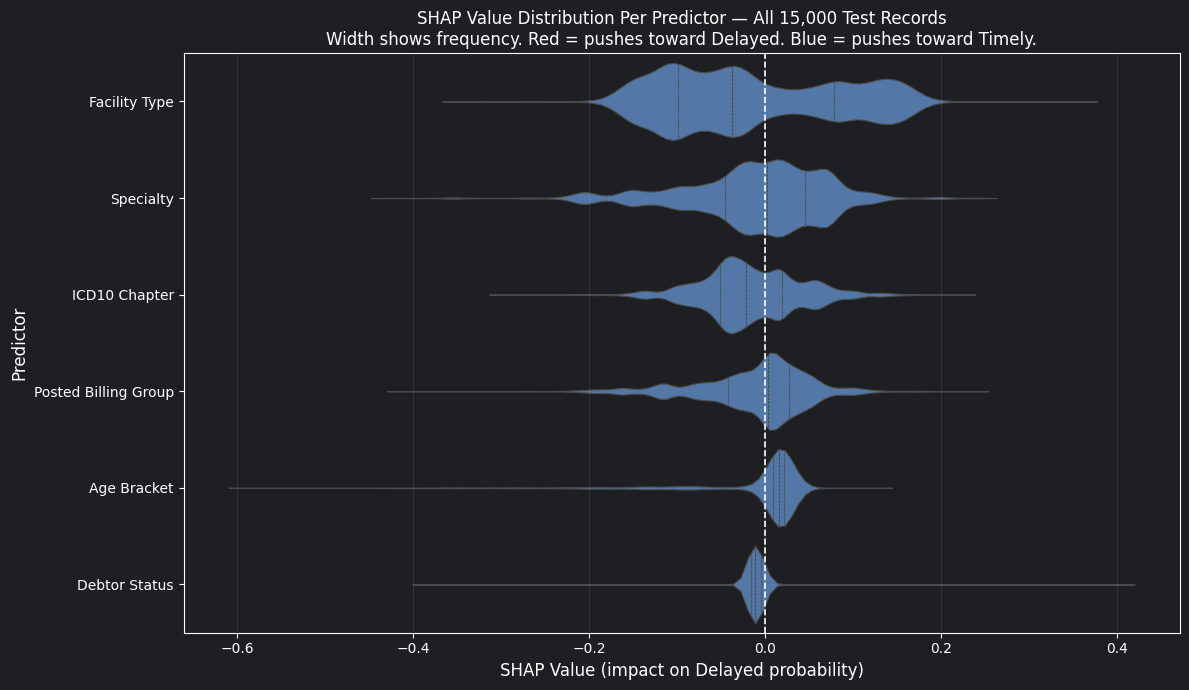

Violin plot saved: shap_violin.png

SHAP COMPLETE SUMMARY TABLE
           Predictor  Mean Abs SHAP  SHAP % of Total  Mean SHAP  Median SHAP  Std SHAP  Max SHAP  Min SHAP  RF Gini Importance  DT Gini Importance
       Facility Type         0.0892          28.9697    -0.0163      -0.0384    0.1003    0.3479   -0.3380              0.1988              0.2459
           Specialty         0.0604          19.6088    -0.0112       0.0014    0.0809    0.2397   -0.4246              0.1825              0.2646
       ICD10 Chapter         0.0480          15.5775    -0.0168      -0.0225    0.0579    0.2219   -0.2970              0.1770              0.0763
Posted Billing Group         0.0468          15.1791    -0.0123       0.0034    0.0653    0.2348   -0.4114              0.1762              0.1585
         Age Bracket         0.0451          14.6373    -0.0162       0.0160    0.0881    0.1183   -0.5840              0.1710              0.1307
       Debtor Status         0.0186           6.0276  

In [11]:
# ============================================================
# CELL 6: SHAP INTERACTION EFFECTS AND FINAL SUMMARY
# We produce one final plot showing SHAP interaction values
# between the two most important predictors:
# Facility Type and Specialty.
# This shows whether the combination of facility type and
# specialty produces effects beyond what each alone would
# predict — a genuine interaction effect.
# Then we save a complete SHAP summary table.
# ============================================================

figures_path = r'C:\2026\MedicalBillingResearch\outputs\figures'

# ── Plot: SHAP values by original variable — violin plot ──
# Shows distribution of SHAP values for each predictor
# across all 15,000 test records
# Positive SHAP = pushes toward Delayed
# Negative SHAP = pushes toward Timely

fig, ax = plt.subplots(figsize=(12, 7))

# Prepare data for violin plot
shap_melted = shap_agg.melt(var_name='Predictor',
                             value_name='SHAP Value')

# Order by mean absolute SHAP
order = shap_agg.abs().mean().sort_values(
    ascending=False).index.tolist()

# Color by mean direction
palette = {}
for var in order:
    mean_val = shap_agg[var].mean()
    palette[var] = '#d73027' if mean_val > 0 else '#4575b4'

sns.violinplot(
    data=shap_melted,
    x='SHAP Value',
    y='Predictor',
    order=order,
    palette=palette,
    ax=ax,
    inner='quartile',
    linewidth=0.8
)

ax.axvline(x=0, color='white', linewidth=1.2, linestyle='--')
ax.set_title(
    'SHAP Value Distribution Per Predictor — All 15,000 Test Records\n'
    'Width shows frequency. Red = pushes toward Delayed. '
    'Blue = pushes toward Timely.',
    fontsize=12
)
ax.set_xlabel('SHAP Value (impact on Delayed probability)', fontsize=12)
ax.set_ylabel('Predictor', fontsize=12)
ax.grid(True, axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig(f'{figures_path}\\shap_violin.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Violin plot saved: shap_violin.png")

# ── Save complete SHAP summary table ─────────────────────
print("\n" + "=" * 60)
print("SHAP COMPLETE SUMMARY TABLE")
print("=" * 60)

shap_summary = pd.DataFrame({
    'Predictor':          order,
    'Mean Abs SHAP':      [shap_agg[v].abs().mean() for v in order],
    'SHAP % of Total':    [shap_agg[v].abs().mean()/total*100
                           for v in order],
    'Mean SHAP':          [shap_agg[v].mean() for v in order],
    'Median SHAP':        [shap_agg[v].median() for v in order],
    'Std SHAP':           [shap_agg[v].std() for v in order],
    'Max SHAP':           [shap_agg[v].max() for v in order],
    'Min SHAP':           [shap_agg[v].min() for v in order],
    'RF Gini Importance': [0.1988, 0.1825, 0.1770,
                           0.1762, 0.1710, 0.0945],
    'DT Gini Importance': [0.2459, 0.2646, 0.0763,
                           0.1585, 0.1307, 0.1240],
})

pd.set_option('display.float_format', '{:.4f}'.format)
print(shap_summary.to_string(index=False))

shap_summary.to_csv(
    r'C:\2026\MedicalBillingResearch\models\shap_summary.csv',
    index=False
)
print(f"\n  SHAP summary saved to models/shap_summary.csv")

# ── Final SHAP ranking vs Gini comparison ─────────────────
print(f"\n{'=' * 60}")
print("IMPORTANCE RANKING COMPARISON — ALL THREE METHODS")
print("=" * 60)
print(f"\n  {'Predictor':<30} {'SHAP Rank':>10} "
      f"{'RF Gini Rank':>14} {'DT Gini Rank':>13}")
print(f"  {'-'*67}")

shap_rank = {v: i+1 for i, v in enumerate(order)}
rf_rank_order = ['Specialty', 'Facility Type', 'ICD10 Chapter',
                 'Posted Billing Group', 'Age Bracket',
                 'Debtor Status']
dt_rank_order = ['Facility Type', 'Specialty',
                 'Posted Billing Group', 'Age Bracket',
                 'Debtor Status', 'ICD10 Chapter']

rf_rank = {v: i+1 for i, v in enumerate(rf_rank_order)}
dt_rank = {v: i+1 for i, v in enumerate(dt_rank_order)}

for var in order:
    print(f"  {var:<30} {shap_rank[var]:>10} "
          f"{rf_rank.get(var, '-'):>14} "
          f"{dt_rank.get(var, '-'):>13}")

print(f"\n  SHAP analysis complete.")
print(f"  All plots saved to outputs/figures/")
print(f"  Summary saved to models/shap_summary.csv")

In [2]:
# ============================================================
# CELL 7: FRESH START - LOAD DATA AND FIT XGBOOST FOR SHAP
# We reload everything from disk since the kernel was reset.
# Then we fit XGBoost with the same settings as 03f and
# compute SHAP values for explainability analysis.
#
# Functions used:
# pd.read_csv() — Reads CSV file into DataFrame
# pd.get_dummies() — One-Hot Encoding for categorical columns
# .align() — Aligns columns between train and test
# XGBClassifier() — Creates XGBoost classifier
# .fit() — Trains the model
# shap.TreeExplainer() — Creates SHAP explainer for trees
# .shap_values() — Computes SHAP values
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from xgboost import XGBClassifier

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Load data ─────────────────────────────────────────────
train = pd.read_csv(
    r'C:\2026\MedicalBillingResearch\dataset\train_set.csv'
)
test = pd.read_csv(
    r'C:\2026\MedicalBillingResearch\dataset\test_set.csv'
)

X_train = train.drop(columns=['Invoice Number', 'Processing Class'])
y_train = train['Processing Class']
X_test  = test.drop(columns=['Invoice Number', 'Processing Class'])
y_test  = test['Processing Class']

# ── One-Hot Encoding ──────────────────────────────────────
X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  drop_first=True)
X_train_enc, X_test_enc = X_train_enc.align(
    X_test_enc, join='left', axis=1, fill_value=0
)

# ── Encode target ─────────────────────────────────────────
y_train_enc = (y_train == 'Delayed').astype(int)
y_test_enc  = (y_test  == 'Delayed').astype(int)

print("=" * 60)
print("DATA RELOADED")
print("=" * 60)
print(f"  Training records  : {len(X_train_enc):,}")
print(f"  Test records      : {len(X_test_enc):,}")
print(f"  Encoded columns   : {X_train_enc.shape[1]}")

# ── Calculate scale_pos_weight ────────────────────────────
n_negative = (y_train_enc == 0).sum()
n_positive = (y_train_enc == 1).sum()
scale_pos_weight = n_negative / n_positive

# ── Fit XGBoost ───────────────────────────────────────────
print(f"\n{'=' * 60}")
print("FITTING XGBOOST FOR SHAP ANALYSIS")
print("=" * 60)

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_model.fit(X_train_enc, y_train_enc)
print(f"  Model fitted successfully")
print(f"  Trees            : {xgb_model.n_estimators}")
print(f"  Max depth        : {xgb_model.max_depth}")
print(f"  Learning rate    : {xgb_model.learning_rate}")
print(f"  scale_pos_weight : {scale_pos_weight:.4f}")

# ── Compute SHAP values ───────────────────────────────────
print(f"\n  Computing SHAP values on {len(X_test_enc):,} records...")
print(f"  XGBoost SHAP is much faster than Random Forest SHAP")

explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test_enc)

print(f"\n  SHAP computation complete")
print(f"  Type     : {type(shap_values_xgb)}")
if hasattr(shap_values_xgb, 'shape'):
    print(f"  Shape    : {shap_values_xgb.shape}")

# XGBoost returns SHAP values directly for the positive class
shap_delayed_xgb = shap_values_xgb

# Baseline expected value
baseline_xgb = explainer_xgb.expected_value
print(f"\n  Baseline expected value (Delayed log-odds):")
print(f"    {baseline_xgb}")

C:\2026\MedicalBillingResearch\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DATA RELOADED
  Training records  : 35,000
  Test records      : 15,000
  Encoded columns   : 43

FITTING XGBOOST FOR SHAP ANALYSIS
  Model fitted successfully
  Trees            : 500
  Max depth        : 6
  Learning rate    : 0.1
  scale_pos_weight : 3.1533

  Computing SHAP values on 15,000 records...
  XGBoost SHAP is much faster than Random Forest SHAP

  SHAP computation complete
  Type     : <class 'numpy.ndarray'>
  Shape    : (15000, 43)

  Baseline expected value (Delayed log-odds):
    -0.0017524113645777106


In [4]:
# ============================================================
# CELL 8: AGGREGATE SHAP TO ORIGINAL VARIABLE LEVEL
# SHAP values are at the encoded dummy column level (43 cols).
# We aggregate back to the original 6 predictor level by
# summing all dummy columns belonging to the same variable.
# This gives us a clean per-predictor importance ranking.
#
# Functions used:
# pd.DataFrame() — Creates DataFrame from numpy array
# .startswith() — String method to check column prefix
# .groupby() — Implicit through dict + sum
# .abs() — Absolute value (for mean absolute SHAP)
# .mean() — Average across rows
# .sort_values() — Sort DataFrame by column value
# ============================================================

# ── Build encoded-level SHAP DataFrame ────────────────────
shap_df_xgb = pd.DataFrame(
    shap_delayed_xgb,
    columns=X_test_enc.columns
)

print("=" * 60)
print("SHAP VALUES AT ENCODED COLUMN LEVEL")
print("=" * 60)
print(f"  DataFrame shape: {shap_df_xgb.shape}")

# ── Define function to map encoded col to original var ────
def get_original_variable(col):
    predictors = [
        'Posted Billing Group', 'Specialty',
        'Debtor Status', 'ICD10 Chapter', 'Facility Type'
    ]
    for pred in predictors:
        if col.startswith(pred):
            return pred
    return col  # Age Bracket has no prefix

col_to_var = {col: get_original_variable(col)
              for col in X_test_enc.columns}

# ── Aggregate SHAP to original variable level ─────────────
original_vars = list(dict.fromkeys(col_to_var.values()))
shap_agg_xgb = pd.DataFrame()
for var in original_vars:
    cols = [c for c, v in col_to_var.items() if v == var]
    shap_agg_xgb[var] = shap_df_xgb[cols].sum(axis=1)

print(f"  Aggregated to {len(original_vars)} original variables")

# ── Global importance ranking ─────────────────────────────
print(f"\n{'=' * 60}")
print("SHAP GLOBAL IMPORTANCE RANKING — XGBOOST")
print("Mean absolute SHAP value per original variable")
print("=" * 60)

mean_abs_xgb = shap_agg_xgb.abs().mean().sort_values(ascending=False)
total_xgb = mean_abs_xgb.sum()
print(f"\n  {'Variable':<30} {'Mean |SHAP|':>12} {'% of Total':>12}")
print(f"  {'-'*56}")
for var, val in mean_abs_xgb.items():
    pct = val / total_xgb * 100
    bar = '█' * int(pct / 2)
    print(f"  {var:<30} {val:>12.4f} {pct:>11.1f}%  {bar}")

# ── Direction of effect ───────────────────────────────────
print(f"\n{'=' * 60}")
print("SHAP MEAN VALUES — DIRECTION OF EFFECT")
print("Positive = pushes toward Delayed")
print("Negative = pushes toward Timely")
print("=" * 60)
mean_shap_xgb = shap_agg_xgb.mean().sort_values(ascending=False)
for var, val in mean_shap_xgb.items():
    direction = 'pushes → Delayed' if val > 0 else 'pushes → Timely'
    print(f"  {var:<30} {val:>10.4f}  {direction}")

# ── Save SHAP values to disk ──────────────────────────────
shap_df_xgb.to_csv(
    r'C:\2026\MedicalBillingResearch\models'
    r'\shap_values_xgb_encoded.csv',
    index=False
)
shap_agg_xgb.to_csv(
    r'C:\2026\MedicalBillingResearch\models'
    r'\shap_values_xgb_aggregated.csv',
    index=False
)
print(f"\n  SHAP files saved to models/ folder")

SHAP VALUES AT ENCODED COLUMN LEVEL
  DataFrame shape: (15000, 43)
  Aggregated to 6 original variables

SHAP GLOBAL IMPORTANCE RANKING — XGBOOST
Mean absolute SHAP value per original variable

  Variable                        Mean |SHAP|   % of Total
  --------------------------------------------------------
  Facility Type                        0.4405        27.2%  █████████████
  Specialty                            0.3106        19.2%  █████████
  Posted Billing Group                 0.2681        16.6%  ████████
  Age Bracket                          0.2666        16.5%  ████████
  ICD10 Chapter                        0.2340        14.4%  ███████
  Debtor Status                        0.1000         6.2%  ███

SHAP MEAN VALUES — DIRECTION OF EFFECT
Positive = pushes toward Delayed
Negative = pushes toward Timely
  Debtor Status                     -0.0219  pushes → Timely
  Posted Billing Group              -0.0242  pushes → Timely
  ICD10 Chapter                     -0.0725  pu

Refitting XGBoost...
Recomputing SHAP values...
SHAP shape: (15000, 43)


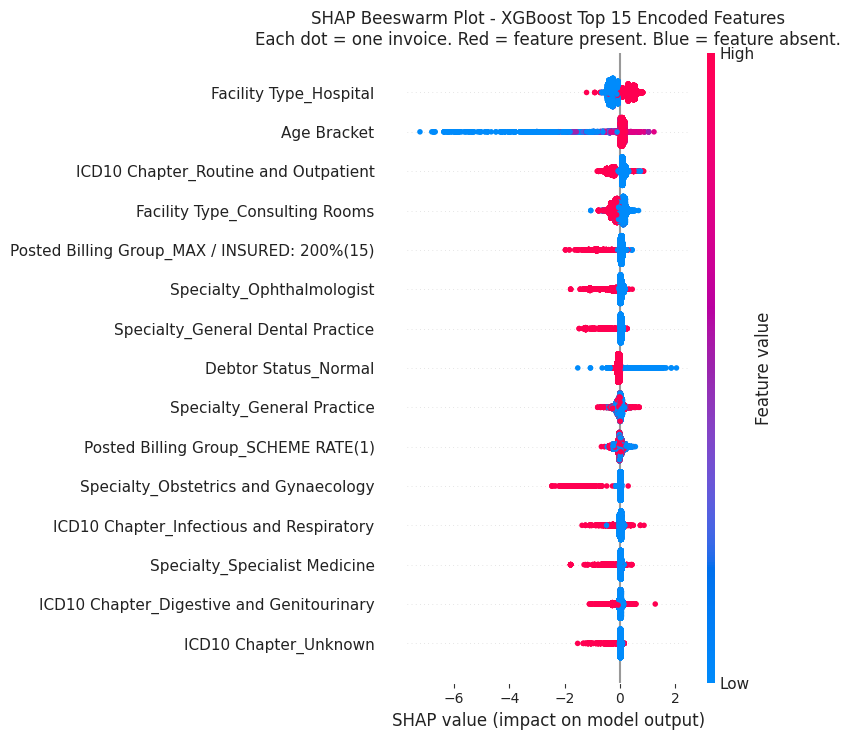

Beeswarm plot saved with readable labels


In [2]:
# ============================================================
# BEESWARM PLOT - SELF-CONTAINED WITH READABLE LABELS
# Reloads data, refits XGBoost, recomputes SHAP, then
# produces the beeswarm plot with a white background and
# dark readable labels suitable for the report.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from xgboost import XGBClassifier

# ── Reload data ───────────────────────────────────────────
train = pd.read_csv(
    r'C:\2026\MedicalBillingResearch\dataset\train_set.csv'
)
test = pd.read_csv(
    r'C:\2026\MedicalBillingResearch\dataset\test_set.csv'
)

X_train = train.drop(columns=['Invoice Number', 'Processing Class'])
y_train = train['Processing Class']
X_test  = test.drop(columns=['Invoice Number', 'Processing Class'])
y_test  = test['Processing Class']

X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  drop_first=True)
X_train_enc, X_test_enc = X_train_enc.align(
    X_test_enc, join='left', axis=1, fill_value=0
)

y_train_enc = (y_train == 'Delayed').astype(int)
y_test_enc  = (y_test  == 'Delayed').astype(int)

# ── Refit XGBoost ─────────────────────────────────────────
n_negative = (y_train_enc == 0).sum()
n_positive = (y_train_enc == 1).sum()
scale_pos_weight = n_negative / n_positive

print("Refitting XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train_enc, y_train_enc)

# ── Recompute SHAP values ─────────────────────────────────
print("Recomputing SHAP values...")
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_delayed_xgb = explainer_xgb.shap_values(X_test_enc)
shap_df_xgb = pd.DataFrame(shap_delayed_xgb, columns=X_test_enc.columns)
print(f"SHAP shape: {shap_delayed_xgb.shape}")

# ── Beeswarm plot with readable labels ────────────────────
top15_features = shap_df_xgb.abs().mean().nlargest(15).index.tolist()
shap_top15 = shap_df_xgb[top15_features].values
X_top15 = X_test_enc[top15_features]

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_top15,
    X_top15,
    feature_names=top15_features,
    plot_type='dot',
    max_display=15,
    show=False
)

# Force all text to dark and background to white
ax = plt.gca()
plt.setp(ax.get_yticklabels(), color='#222222', fontsize=11)
plt.setp(ax.get_xticklabels(), color='#222222', fontsize=10)
ax.xaxis.label.set_color('#222222')
ax.xaxis.label.set_size(12)

fig = plt.gcf()
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Fix colorbar text if present
if len(fig.axes) > 1:
    cbar_ax = fig.axes[-1]
    cbar_ax.yaxis.label.set_color('#222222')
    plt.setp(cbar_ax.get_yticklabels(), color='#222222')

plt.title(
    'SHAP Beeswarm Plot - XGBoost Top 15 Encoded Features\n'
    'Each dot = one invoice. Red = feature present. '
    'Blue = feature absent.',
    fontsize=12, color='#222222'
)

plt.tight_layout()
figures_path = r'C:\2026\MedicalBillingResearch\outputs\figures'
plt.savefig(f'{figures_path}\\shap_beeswarm_xgb.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Beeswarm plot saved with readable labels")

TOP ENCODED FEATURES FOR DEPENDENCE PLOTS — XGBOOST
  Facility Type        : Facility Type_Hospital
  Specialty            : Specialty_Ophthalmologist
  Posted Billing Group : Posted Billing Group_MAX / INSURED: 200%(15)


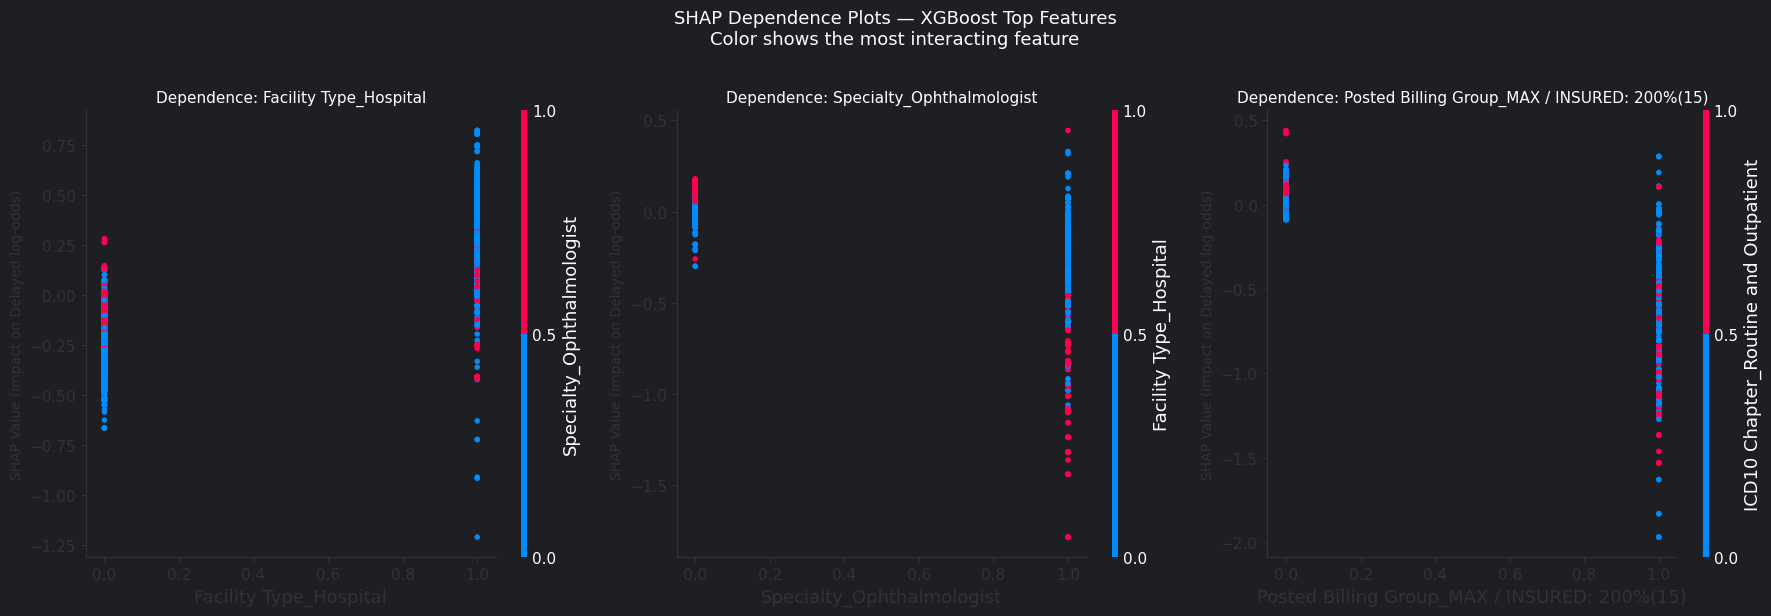

Dependence plots saved: shap_dependence_plots_xgb.png


In [6]:
# ============================================================
# CELL 10: SHAP DEPENDENCE PLOTS — XGBOOST
# Dependence plots show how SHAP values for one feature
# vary across its range of values, with color showing
# the most interacting feature identified by SHAP.
# We produce plots for the top 3 most important encoded
# features within each of the top 3 original predictors.
#
# Functions used:
# .idxmax() — Returns index of maximum value
# shap.dependence_plot() — Built-in dependence plot
# ============================================================

# Find top encoded feature for each top original predictor
top_facility = shap_df_xgb[
    [c for c in shap_df_xgb.columns if c.startswith('Facility Type')]
].abs().mean().idxmax()

top_specialty = shap_df_xgb[
    [c for c in shap_df_xgb.columns if c.startswith('Specialty')]
].abs().mean().idxmax()

# For Posted Billing Group (3rd in XGBoost SHAP)
top_billing = shap_df_xgb[
    [c for c in shap_df_xgb.columns
     if c.startswith('Posted Billing Group')]
].abs().mean().idxmax()

print("=" * 60)
print("TOP ENCODED FEATURES FOR DEPENDENCE PLOTS — XGBOOST")
print("=" * 60)
print(f"  Facility Type        : {top_facility}")
print(f"  Specialty            : {top_specialty}")
print(f"  Posted Billing Group : {top_billing}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, feat_name in zip(axes,
                         [top_facility, top_specialty, top_billing]):
    feat_idx = list(X_test_enc.columns).index(feat_name)
    shap.dependence_plot(
        feat_idx,
        shap_delayed_xgb,
        X_test_enc,
        feature_names=list(X_test_enc.columns),
        ax=ax,
        show=False
    )
    ax.set_title(f'Dependence: {feat_name}', fontsize=11)
    ax.set_ylabel('SHAP Value (impact on Delayed log-odds)',
                  fontsize=10)

plt.suptitle(
    'SHAP Dependence Plots — XGBoost Top Features\n'
    'Color shows the most interacting feature',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig(f'{figures_path}\\shap_dependence_plots_xgb.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Dependence plots saved: shap_dependence_plots_xgb.png")

C:\2026\MedicalBillingResearch\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Refitting XGBoost...
Recomputing SHAP values...
SHAP shape: (15000, 43)

REPRESENTATIVE INVOICES - XGBOOST

  True Negative  (Timely -> Timely)
    Test index     : 1928
    Actual         : Timely
    Predicted      : Timely
    Delayed prob   : 0.0003 (0.0%)
    Invoice features:
      Posted Billing Group           : SCHEME RATE(1)
      Specialty                      : General Practice
      Debtor Status                  : Normal
      Age Bracket                    : 0
      ICD10 Chapter                  : Cardiovascular and Metabolic
      Facility Type                  : Consulting Rooms

  True Positive  (Delayed -> Delayed)
    Test index     : 1705
    Actual         : Delayed
    Predicted      : Delayed
    Delayed prob   : 0.9922 (99.2%)
    Invoice features:
      Posted Billing Group           : Unknown
      Specialty                      : Mental Health
      Debtor Status                  : Active Collection
      Age Bracket                    : 180
      ICD10 Cha

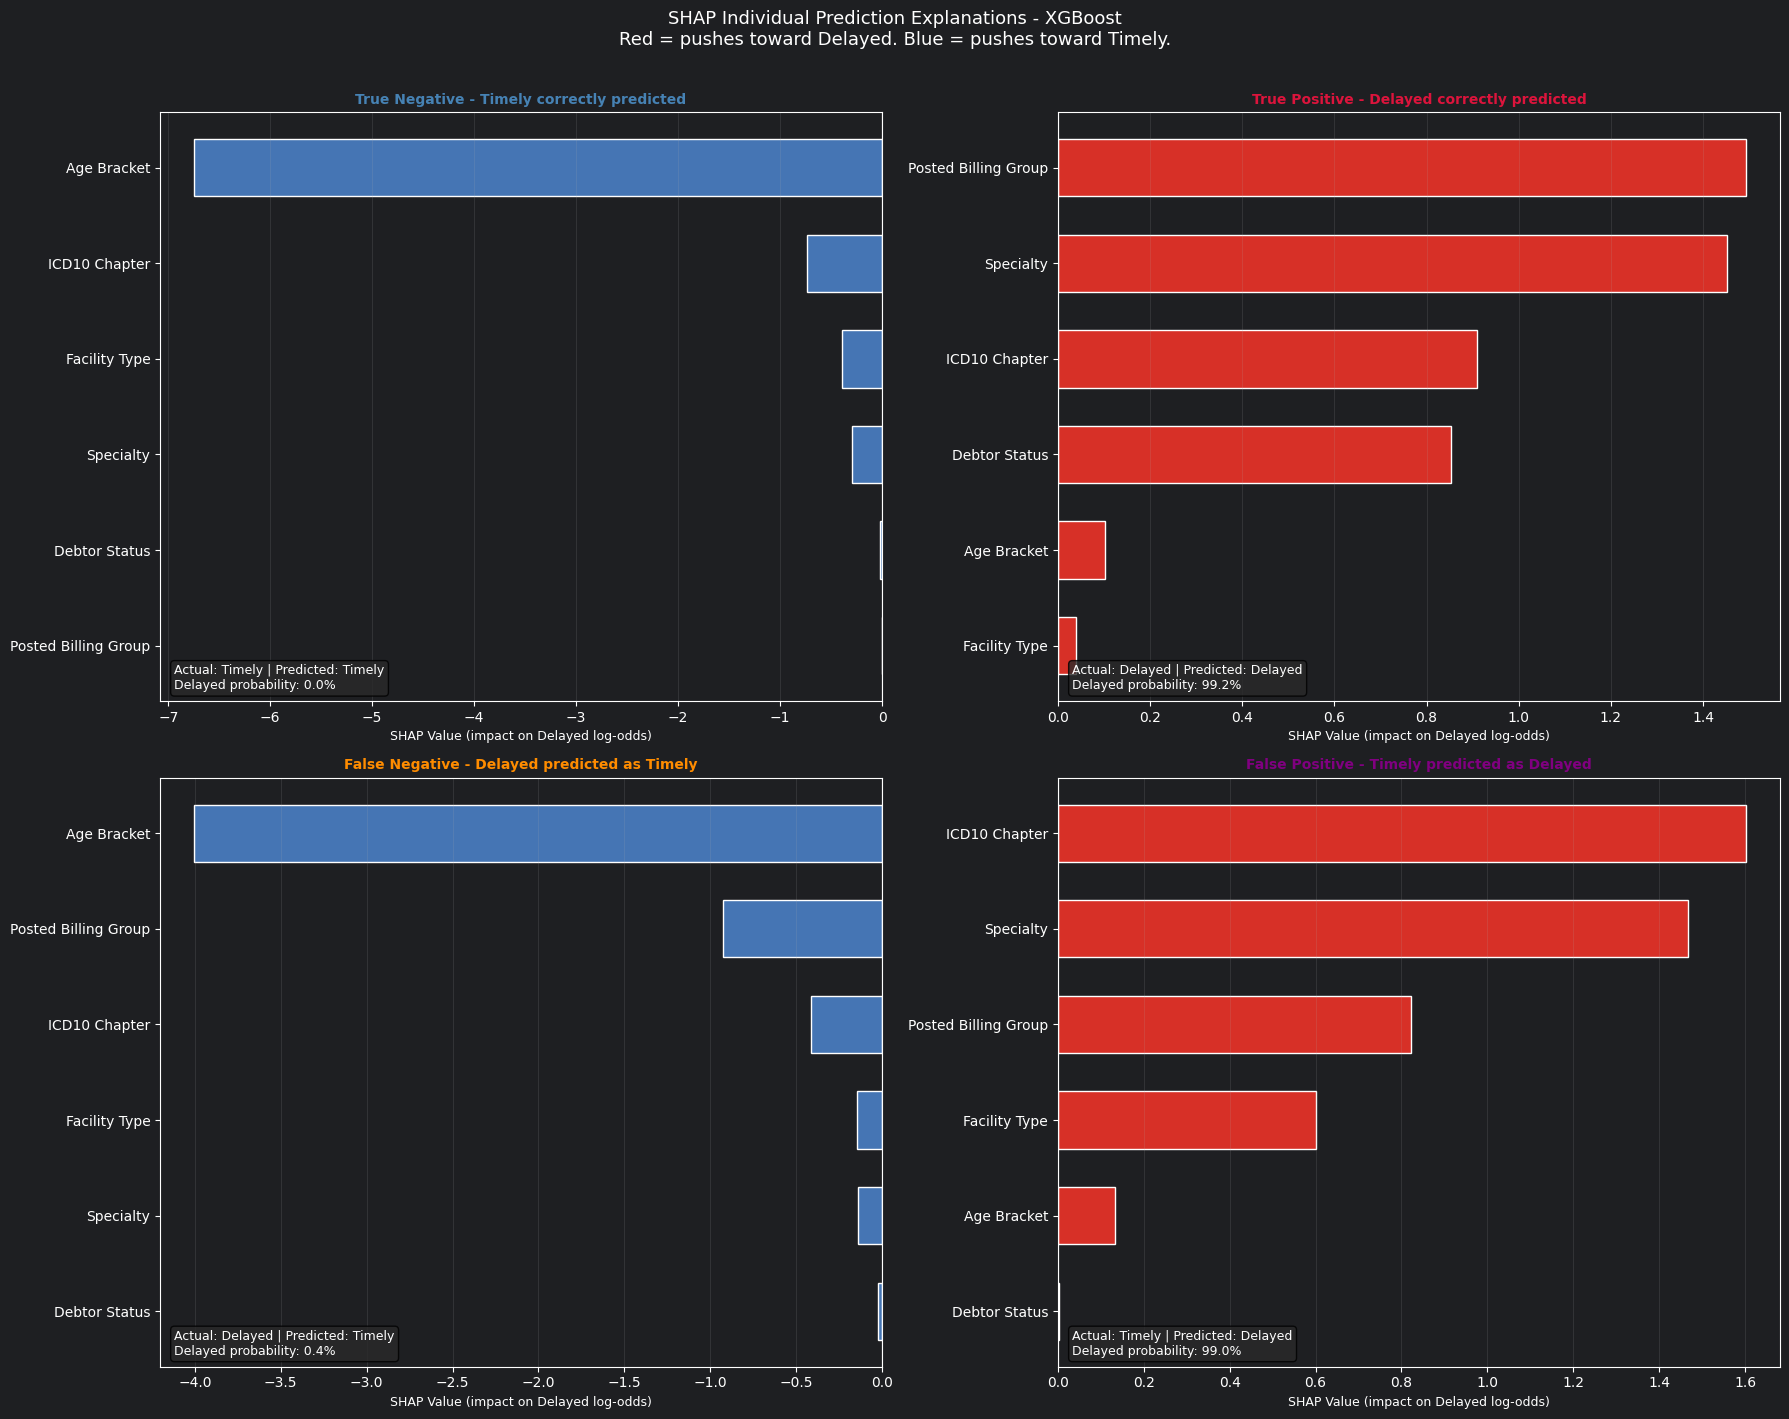


Plot saved: shap_individual_predictions_xgb.png


In [4]:
# ============================================================
# CELL 11: INDIVIDUAL PREDICTIONS - SELF-CONTAINED VERSION
# Kernel was reset so we reload all dependencies, refit
# XGBoost, recompute SHAP, then produce the individual
# prediction plots. All in one cell.
#
# This is slower than running cells sequentially but is
# robust to kernel resets.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from xgboost import XGBClassifier

pd.set_option('display.max_columns', None)

# ── Reload data ───────────────────────────────────────────
train = pd.read_csv(
    r'C:\2026\MedicalBillingResearch\dataset\train_set.csv'
)
test = pd.read_csv(
    r'C:\2026\MedicalBillingResearch\dataset\test_set.csv'
)

X_train = train.drop(columns=['Invoice Number', 'Processing Class'])
y_train = train['Processing Class']
X_test  = test.drop(columns=['Invoice Number', 'Processing Class'])
y_test  = test['Processing Class']

X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  drop_first=True)
X_train_enc, X_test_enc = X_train_enc.align(
    X_test_enc, join='left', axis=1, fill_value=0
)

y_train_enc = (y_train == 'Delayed').astype(int)
y_test_enc  = (y_test  == 'Delayed').astype(int)

# ── Refit XGBoost ─────────────────────────────────────────
n_negative = (y_train_enc == 0).sum()
n_positive = (y_train_enc == 1).sum()
scale_pos_weight = n_negative / n_positive

print("Refitting XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train_enc, y_train_enc)

# ── Recompute SHAP values ─────────────────────────────────
print("Recomputing SHAP values...")
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_delayed_xgb = explainer_xgb.shap_values(X_test_enc)
print(f"SHAP shape: {shap_delayed_xgb.shape}")

# ── Setup variable aggregation ────────────────────────────
def get_original_variable(col):
    predictors = [
        'Posted Billing Group', 'Specialty',
        'Debtor Status', 'ICD10 Chapter', 'Facility Type'
    ]
    for pred in predictors:
        if col.startswith(pred):
            return pred
    return col

col_to_var = {col: get_original_variable(col)
              for col in X_test_enc.columns}
original_vars = list(dict.fromkeys(col_to_var.values()))

# ── Get predictions ───────────────────────────────────────
y_pred_xgb = xgb_model.predict(X_test_enc)
y_prob_xgb = xgb_model.predict_proba(X_test_enc)[:, 1]

# ── Find representative cases ─────────────────────────────
tn_idx = np.where(
    (y_test_enc.values == 0) & (y_pred_xgb == 0))[0]
tp_idx = np.where(
    (y_test_enc.values == 1) & (y_pred_xgb == 1))[0]
fn_idx = np.where(
    (y_test_enc.values == 1) & (y_pred_xgb == 0))[0]
fp_idx = np.where(
    (y_test_enc.values == 0) & (y_pred_xgb == 1))[0]

tn_pick = tn_idx[np.argmin(y_prob_xgb[tn_idx])]
tp_pick = tp_idx[np.argmax(y_prob_xgb[tp_idx])]
fn_pick = fn_idx[np.argmin(y_prob_xgb[fn_idx])]
fp_pick = fp_idx[np.argmax(y_prob_xgb[fp_idx])]

print("\n" + "=" * 60)
print("REPRESENTATIVE INVOICES - XGBOOST")
print("=" * 60)
for label, idx in [
    ('True Negative  (Timely -> Timely)',   tn_pick),
    ('True Positive  (Delayed -> Delayed)', tp_pick),
    ('False Negative (Delayed -> Timely)',  fn_pick),
    ('False Positive (Timely -> Delayed)',  fp_pick),
]:
    actual    = 'Delayed' if y_test_enc.values[idx] == 1 else 'Timely'
    predicted = 'Delayed' if y_pred_xgb[idx] == 1 else 'Timely'
    prob      = y_prob_xgb[idx]
    print(f"\n  {label}")
    print(f"    Test index     : {idx}")
    print(f"    Actual         : {actual}")
    print(f"    Predicted      : {predicted}")
    print(f"    Delayed prob   : {prob:.4f} ({prob*100:.1f}%)")
    print(f"    Invoice features:")
    for col in X_test.columns:
        val = X_test.iloc[idx][col]
        print(f"      {col:<30} : {val}")

# ── Plot individual SHAP explanations ─────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

cases = [
    (tn_pick, 'True Negative - Timely correctly predicted',
     'steelblue'),
    (tp_pick, 'True Positive - Delayed correctly predicted',
     'crimson'),
    (fn_pick, 'False Negative - Delayed predicted as Timely',
     'darkorange'),
    (fp_pick, 'False Positive - Timely predicted as Delayed',
     'purple'),
]

for ax, (idx, title, color) in zip(axes, cases):
    record_shap = shap_delayed_xgb[idx]

    record_shap_agg = {}
    for var in original_vars:
        cols = [c for c, v in col_to_var.items() if v == var]
        col_indices = [
            list(X_test_enc.columns).index(c) for c in cols
        ]
        record_shap_agg[var] = sum(
            record_shap[i] for i in col_indices
        )

    sorted_vars = sorted(
        record_shap_agg.items(),
        key=lambda x: abs(x[1]), reverse=True
    )
    var_names  = [v for v, s in sorted_vars]
    shap_vals  = [s for v, s in sorted_vars]
    colors_bar = ['#d73027' if s > 0 else '#4575b4'
                  for s in shap_vals]

    ax.barh(var_names[::-1], shap_vals[::-1],
            color=colors_bar[::-1], edgecolor='white', height=0.6)
    ax.axvline(x=0, color='white', linewidth=0.8)
    ax.set_title(title, fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('SHAP Value (impact on Delayed log-odds)',
                  fontsize=9)

    prob = y_prob_xgb[idx]
    actual = 'Delayed' if y_test_enc.values[idx] == 1 else 'Timely'
    predicted = 'Delayed' if y_pred_xgb[idx] == 1 else 'Timely'
    ax.text(0.02, 0.02,
            f'Actual: {actual} | Predicted: {predicted}\n'
            f'Delayed probability: {prob*100:.1f}%',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='#2a2a2a',
                      alpha=0.8),
            color='white')
    ax.grid(True, axis='x', alpha=0.2)

plt.suptitle(
    'SHAP Individual Prediction Explanations - XGBoost\n'
    'Red = pushes toward Delayed. Blue = pushes toward Timely.',
    fontsize=13, y=1.01
)
plt.tight_layout()
figures_path = r'C:\2026\MedicalBillingResearch\outputs\figures'
plt.savefig(f'{figures_path}\\shap_individual_predictions_xgb.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: shap_individual_predictions_xgb.png")

C:\Users\Admin\AppData\Local\Temp\ipykernel_3232\700024937.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


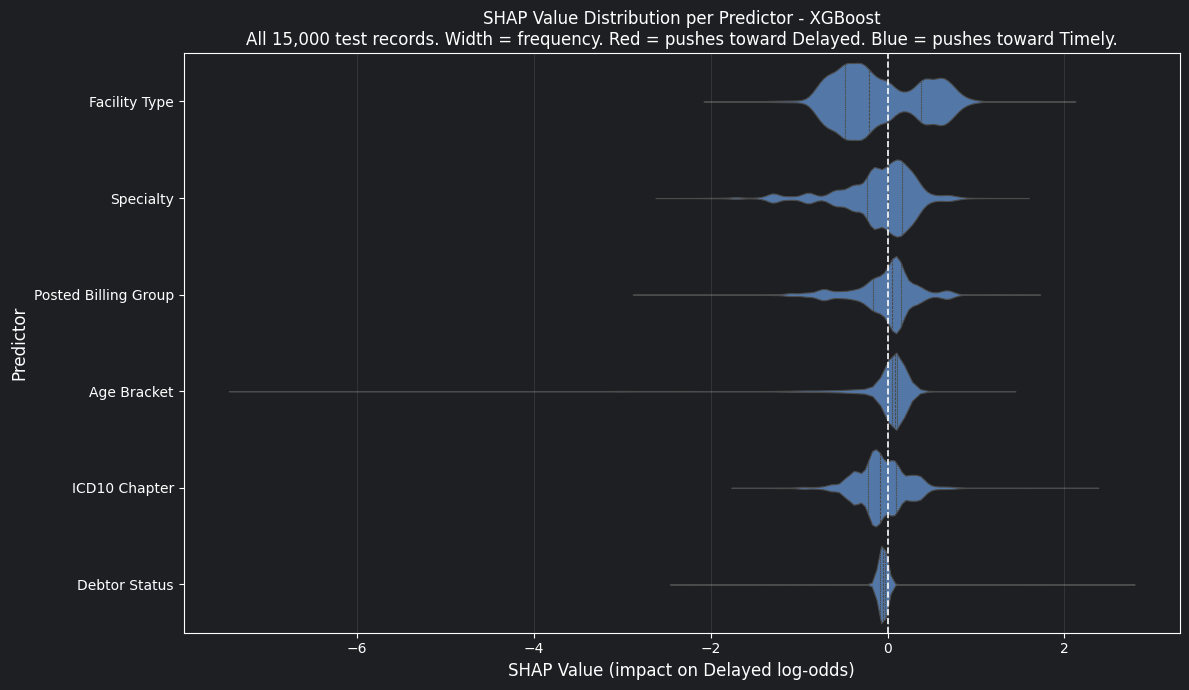

Violin plot saved: shap_violin_xgb.png

SHAP COMPLETE SUMMARY - XGBOOST
           Predictor  Mean Abs SHAP  Mean SHAP  Median SHAP  Max SHAP  Min SHAP
       Facility Type         0.4405    -0.0957      -0.2090    1.9792   -1.9381
           Specialty         0.3106    -0.0993       0.0019    1.4677   -2.4975
Posted Billing Group         0.2681    -0.0242       0.0475    1.6112   -2.7682
         Age Bracket         0.2666    -0.1131       0.0785    1.2317   -7.2370
       ICD10 Chapter         0.2340    -0.0725      -0.0896    2.2959   -1.6813
       Debtor Status         0.1000    -0.0219      -0.0547    2.7237   -2.3922

SHAP summary saved to: models/shap_summary_xgb.csv

XGBoost SHAP analysis - COMPLETE


In [5]:
# ============================================================
# CELL 12: SHAP VIOLIN PLOT FOR XGBOOST
# Shows the full distribution of SHAP values for each
# predictor across all 15,000 test records.
# Width of violin = frequency of SHAP values at that level.
# Color = direction of mean effect (red toward Delayed,
# blue toward Timely).
#
# Functions used:
# pd.DataFrame.melt() — Reshapes wide to long format
# sns.violinplot() — Creates the violin plot
# ============================================================

import seaborn as sns

# Build aggregated SHAP DataFrame for plotting
shap_agg_xgb = pd.DataFrame()
for var in original_vars:
    cols = [c for c, v in col_to_var.items() if v == var]
    shap_agg_xgb[var] = pd.DataFrame(
        shap_delayed_xgb, columns=X_test_enc.columns
    )[cols].sum(axis=1)

# Melt to long format for seaborn
shap_melted = shap_agg_xgb.melt(
    var_name='Predictor',
    value_name='SHAP Value'
)

# Order by mean absolute SHAP value (importance)
order = shap_agg_xgb.abs().mean().sort_values(
    ascending=False
).index.tolist()

# Color by direction of mean effect
palette = {}
for var in order:
    mean_val = shap_agg_xgb[var].mean()
    palette[var] = '#d73027' if mean_val > 0 else '#4575b4'

fig, ax = plt.subplots(figsize=(12, 7))
sns.violinplot(
    data=shap_melted,
    x='SHAP Value',
    y='Predictor',
    order=order,
    palette=palette,
    ax=ax,
    inner='quartile',
    linewidth=0.8
)

ax.axvline(x=0, color='white', linewidth=1.2, linestyle='--')
ax.set_title(
    'SHAP Value Distribution per Predictor - XGBoost\n'
    'All 15,000 test records. Width = frequency. '
    'Red = pushes toward Delayed. Blue = pushes toward Timely.',
    fontsize=12
)
ax.set_xlabel('SHAP Value (impact on Delayed log-odds)',
              fontsize=12)
ax.set_ylabel('Predictor', fontsize=12)
ax.grid(True, axis='x', alpha=0.2)
plt.tight_layout()

figures_path = r'C:\2026\MedicalBillingResearch\outputs\figures'
plt.savefig(f'{figures_path}\\shap_violin_xgb.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Violin plot saved: shap_violin_xgb.png")

# ── Final summary table ───────────────────────────────────
print("\n" + "=" * 60)
print("SHAP COMPLETE SUMMARY - XGBOOST")
print("=" * 60)

shap_summary_xgb = pd.DataFrame({
    'Predictor':       order,
    'Mean Abs SHAP':   [shap_agg_xgb[v].abs().mean() for v in order],
    'Mean SHAP':       [shap_agg_xgb[v].mean() for v in order],
    'Median SHAP':     [shap_agg_xgb[v].median() for v in order],
    'Max SHAP':        [shap_agg_xgb[v].max() for v in order],
    'Min SHAP':        [shap_agg_xgb[v].min() for v in order],
})

pd.set_option('display.float_format', '{:.4f}'.format)
print(shap_summary_xgb.to_string(index=False))

shap_summary_xgb.to_csv(
    r'C:\2026\MedicalBillingResearch\models\shap_summary_xgb.csv',
    index=False
)
print("\nSHAP summary saved to: models/shap_summary_xgb.csv")
print("\nXGBoost SHAP analysis - COMPLETE")